# Week 4 · Algorithm Comparison
Business Rehearsal Outcome Predictor · Spring 2026

Side-by-side evaluation of all three models on the same temporal test split.

| Model | Intervals | Key idea |
|---|---|---|
| Ridge baseline | residual ±z·σ | weighted linear sum |
| XGBoost | quantile regression | gradient-boosted trees |
| FT-Transformer | joint quantile head | self-attention over feature tokens |

> **Training time**: the Transformer takes ~1–3 min. Run this notebook once
> and keep the results dict in memory for the plots.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 4),
                     'axes.spines.top': False, 'axes.spines.right': False})

from models.baseline     import (load_features, temporal_split,
                                  train_baseline,    print_results as pr_bl)
from models.xgboost_model import (train_xgboost,    print_results as pr_xg)
from models.transformer_model import (train_transformer, print_results as pr_tr)

TARGETS = [
    'label_inventory_delta',
    'label_cashflow_delta',
    'label_order_velocity_delta',
]
SHORT = {
    'label_inventory_delta':      'Inventory',
    'label_cashflow_delta':       'Cash Flow',
    'label_order_velocity_delta': 'Order Velocity',
}


In [2]:
df = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)

print('=== Baseline ===')
bl = train_baseline(train, test);    pr_bl(bl)

print('\n=== XGBoost ===')
xg = train_xgboost(train, test);     pr_xg(xg)

print('\n=== Transformer ===')
tr = train_transformer(train, test); pr_tr(tr)


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423
=== Baseline ===

Target                        MAPE    Calibration (80% CI)
───────────────────────────────────────────────────────────
  Inventory Delta         320.4%    0.89  (target: 0.80)
  Cash Flow Delta         134.7%    0.91  (target: 0.80)
  Order Velocity Delta    127.8%    0.82  (target: 0.80)

Interpretation guide:
  MAPE < 15%   → strong baseline
  MAPE 15-30%  → acceptable, useful for a founder
  MAPE > 30%   → weak — XGBoost should beat this comfortably

  Calibration near 0.80 → prediction intervals are honest
  Calibration >> 0.80   → intervals too wide
  Calibration << 0.80   → intervals too narrow

=== XGBoost ===

Training: inventory
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model done
  lower qua

## Summary table
Lower MAPE = better accuracy. Calibration closer to 0.80 = more honest intervals.

In [3]:
rows = []
for model_name, res in [('Baseline', bl), ('XGBoost', xg), ('Transformer', tr)]:
    for target, r in res.items():
        rows.append({
            'Model':   model_name,
            'Target':  SHORT[target],
            'MAPE':    round(r['mape'], 1),
            'Cal':     round(r['calibration'], 2),
        })

summary = pd.DataFrame(rows)
pivot_mape = summary.pivot(index='Target', columns='Model', values='MAPE')
pivot_cal  = summary.pivot(index='Target', columns='Model', values='Cal')

print('MAPE (%) — lower is better')
display(pivot_mape)
print('\nCalibration — target 0.80')
display(pivot_cal)


MAPE (%) — lower is better


Model,Baseline,Transformer,XGBoost
Target,,,
Cash Flow,134.7,99.0,90.9
Inventory,320.4,69.4,123.4
Order Velocity,127.8,67.7,90.5



Calibration — target 0.80


Model,Baseline,Transformer,XGBoost
Target,,,
Cash Flow,0.91,0.00,0.75
Inventory,0.89,0.62,0.68
Order Velocity,0.82,0.68,0.70


## Visual comparison

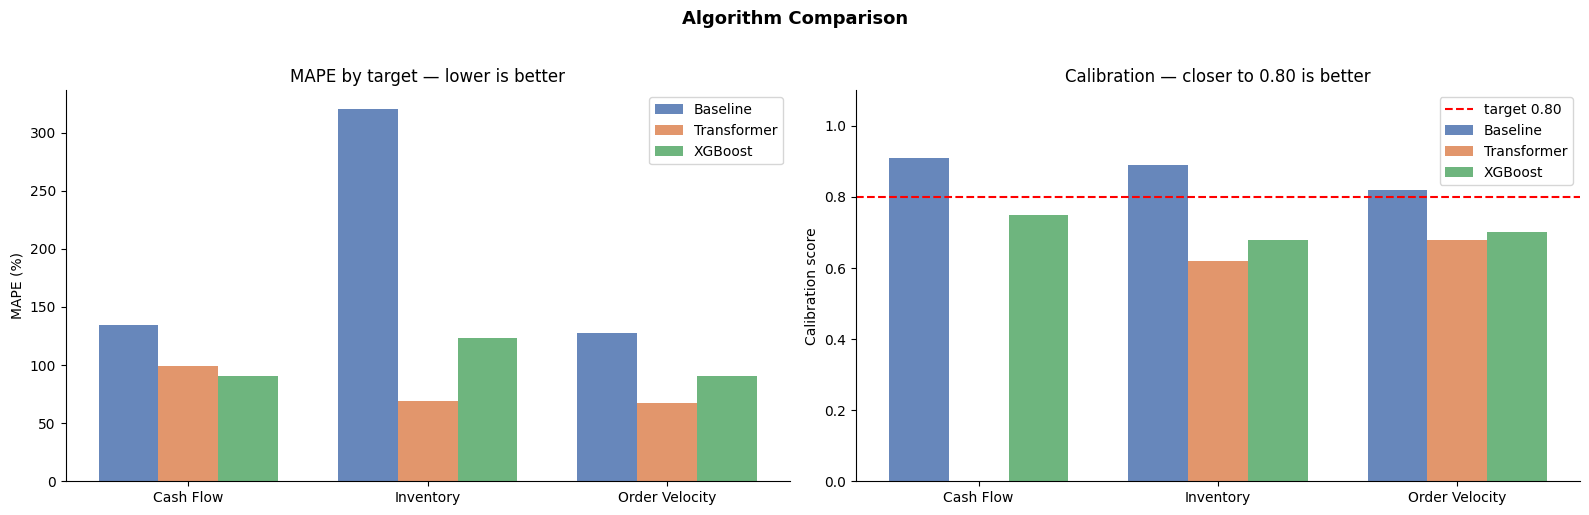

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# MAPE grouped bar
targets = pivot_mape.index.tolist()
models  = pivot_mape.columns.tolist()
x       = np.arange(len(targets))
w       = 0.25
colors  = ['#4C72B0', '#DD8452', '#55A868']

for i, (model, color) in enumerate(zip(models, colors)):
    ax1.bar(x + i*w, pivot_mape[model], w, label=model, color=color, alpha=0.85)
ax1.set_xticks(x + w)
ax1.set_xticklabels(targets)
ax1.set_ylabel('MAPE (%)')
ax1.set_title('MAPE by target — lower is better')
ax1.legend()

# Calibration grouped bar
for i, (model, color) in enumerate(zip(models, colors)):
    ax2.bar(x + i*w, pivot_cal[model], w, label=model, color=color, alpha=0.85)
ax2.axhline(0.80, color='red', linestyle='--', lw=1.5, label='target 0.80')
ax2.set_xticks(x + w)
ax2.set_xticklabels(targets)
ax2.set_ylabel('Calibration score')
ax2.set_ylim(0, 1.1)
ax2.set_title('Calibration — closer to 0.80 is better')
ax2.legend()

plt.suptitle('Algorithm Comparison', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## Notes

In [5]:
# ── Which model wins? ────────────────────────────────────────────────────────
best_mape = pivot_mape.idxmin(axis=1)
best_cal  = (pivot_cal - 0.80).abs().idxmin(axis=1)

print('Best MAPE per target:')
for t, m in best_mape.items(): print(f'  {t:<18} → {m}')

print('\nBest calibration per target (closest to 0.80):')
for t, m in best_cal.items(): print(f'  {t:<18} → {m}')


Best MAPE per target:
  Cash Flow          → XGBoost
  Inventory          → Transformer
  Order Velocity     → Transformer

Best calibration per target (closest to 0.80):
  Cash Flow          → XGBoost
  Inventory          → Baseline
  Order Velocity     → Baseline
